In [ ]:
import numpy as np
from scipy.io import loadmat
import keras
import keras.backend as K
from keras.layers import Dense, Activation, LeakyReLU, BatchNormalization
from keras.layers import Conv2D, Conv2DTranspose, Reshape, Flatten
from keras.models import Sequential
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
!wget http://ufldl.stanford.edu/housenumbers/train_32x32.mat
!wget http://ufldl.stanford.edu/housenumbers/test_32x32.mat

--2025-03-29 08:43:43--  http://ufldl.stanford.edu/housenumbers/train_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182040794 (174M) [text/plain]
Saving to: ‘train_32x32.mat’

train_32x32.mat     100%[===================>] 173.61M  13.3MB/s    in 48s     

2025-03-29 08:44:31 (3.63 MB/s) - ‘train_32x32.mat’ saved [182040794/182040794]

--2025-03-29 08:44:31--  http://ufldl.stanford.edu/housenumbers/test_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64275384 (61M) [text/plain]
Saving to: ‘test_32x32.mat’

test_32x32.mat      100%[===================>]  61.30M  1.63MB/s    in 44s     

2025-03-29 08:45:16 (1.40 MB/s) - ‘test_32x32.mat’ saved [64275384/64

In [ ]:
train_data = loadmat('train_32x32.mat')
test_data  = loadmat('test_32x32.mat')

In [ ]:
X_train, y_train = train_data['X'], train_data['y']
X_test,  y_test  = test_data['X'],  test_data['y']

X_train.shape

(32, 32, 3, 73257)

In [ ]:
# roll axis backward

X_train = np.rollaxis(X_train, 3)
X_test  = np.rollaxis(X_test, 3)

X_train.shape

(73257, 32, 32, 3)

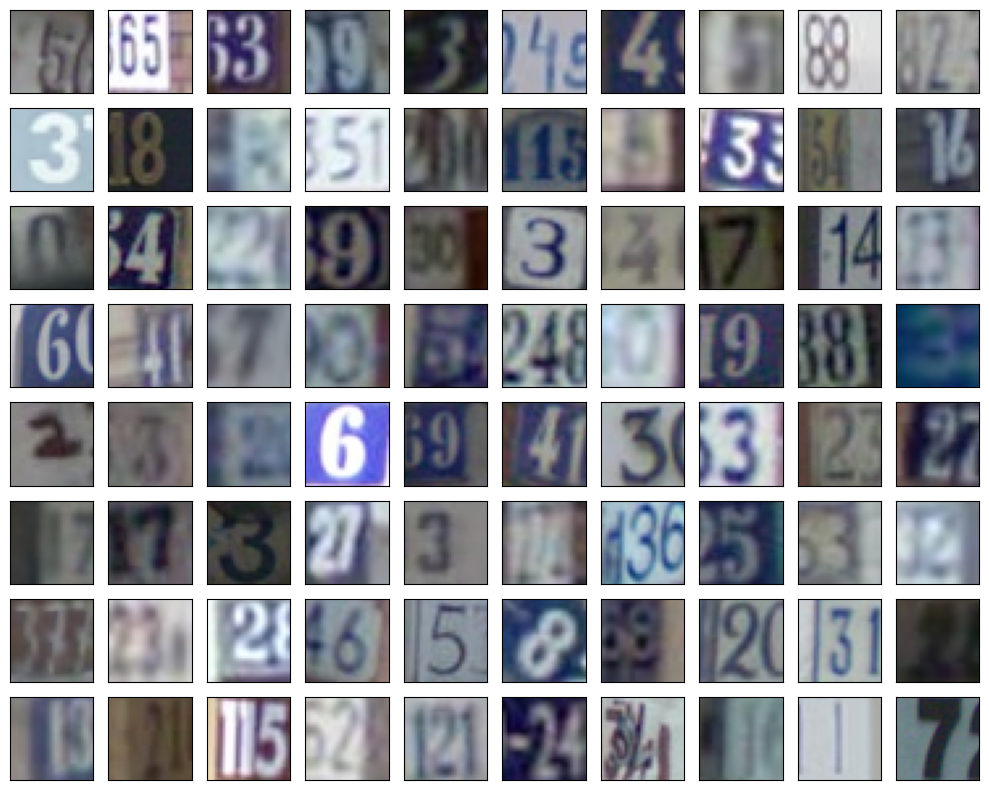

In [ ]:
sample_images = X_train[np.random.choice(len(X_train), size=80, replace=False)]

plt.figure(figsize=(10, 8))
for i in range(80):
    plt.subplot(8, 10, i+1)
    plt.imshow(sample_images[i])
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

In [ ]:
def preprocess(x):
    return (x/255)*2-1

def deprocess(x):
    return np.uint8((x+1)/2*255) # make sure to use uint8 type otherwise the image won't display properly

In [ ]:
X_train_real = preprocess(X_train)
X_test_real  = preprocess(X_test)

In [ ]:
def make_generator(input_size, leaky_alpha):
    # generates images in (32,32,3)
    return Sequential([
        Dense(4*4*512, input_shape=(input_size,)),
        Reshape(target_shape=(4, 4, 512)),                              # 4,4,512
        BatchNormalization(),
        LeakyReLU(alpha=leaky_alpha),
        Conv2DTranspose(256, kernel_size=5, strides=2, padding='same'), # 8,8,256
        BatchNormalization(),
        LeakyReLU(alpha=leaky_alpha),
        Conv2DTranspose(128, kernel_size=5, strides=2, padding='same'), # 16,16,128
        BatchNormalization(),
        LeakyReLU(alpha=leaky_alpha),
        Conv2DTranspose(3, kernel_size=5, strides=2, padding='same'),   # 32,32,3
        Activation('tanh')
    ])

In [ ]:
def make_discriminator(leaky_alpha):
    # classifies images in (32,32,3)
    return Sequential([
        Conv2D(64, kernel_size=5, strides=2, padding='same',     # 16,16,64
               input_shape=(32,32,3)),
        LeakyReLU(alpha=leaky_alpha),
        Conv2D(128, kernel_size=5, strides=2, padding='same'),   # 8,8,128
        BatchNormalization(),
        LeakyReLU(alpha=leaky_alpha),
        Conv2D(256, kernel_size=5, strides=2, padding='same'),   # 4,4,256
        BatchNormalization(),
        LeakyReLU(alpha=leaky_alpha),
        Flatten(),
        Dense(1),
        Activation('sigmoid')
    ])

In [ ]:
# beta_1 is the exponential decay rate for the 1st moment estimates in Adam optimizer
def make_DCGAN(sample_size,
               g_learning_rate,
               g_beta_1,
               d_learning_rate,
               d_beta_1,
               leaky_alpha):
    # clear any session data
    K.clear_session()

    # generator
    generator = make_generator(sample_size, leaky_alpha)

    # discriminator
    discriminator = make_discriminator(leaky_alpha)
    discriminator.compile(optimizer=Adam(learning_rate=d_learning_rate, beta_1=d_beta_1), loss='binary_crossentropy')

    # GAN
    gan = Sequential([generator, discriminator])
    gan.compile(optimizer=Adam(learning_rate=g_learning_rate, beta_1=g_beta_1), loss='binary_crossentropy')

    return gan, generator, discriminator

In [ ]:
def make_latent_samples(n_samples, sample_size):
    #return np.random.uniform(-1, 1, size=(n_samples, sample_size))
    return np.random.normal(loc=0, scale=1, size=(n_samples, sample_size))

In [ ]:
def make_trainable(model, trainable):
    for layer in model.layers:
        layer.trainable = trainable

In [ ]:
def make_labels(size):
    return np.ones([size, 1]), np.zeros([size, 1])

In [ ]:
def show_losses(losses):
    losses = np.array(losses)

    fig, ax = plt.subplots()
    plt.plot(losses.T[0], label='Discriminator')
    plt.plot(losses.T[1], label='Generator')
    plt.title("Validation Losses")
    plt.legend()
    plt.show()

In [ ]:
def show_images(generated_images):
    n_images = len(generated_images)
    cols = 10
    rows = n_images//cols

    plt.figure(figsize=(10, 8))
    for i in range(n_images):
        img = deprocess(generated_images[i])
        ax = plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
    plt.tight_layout()
    plt.show()

In [ ]:
def train(
    g_learning_rate, # learning rate for the generator
    g_beta_1,        # the exponential decay rate for the 1st moment estimates in Adam optimizer
    d_learning_rate, # learning rate for the discriminator
    d_beta_1,        # the exponential decay rate for the 1st moment estimates in Adam optimizer
    leaky_alpha,
    smooth=0.1,
    sample_size=100, # latent sample size (i.e. 100 random numbers)
    epochs=25,
    batch_size= 128, # train batch size
    eval_size=16,    # evaluate size
    show_details=True):

    # labels for the batch size and the test size
    y_train_real, y_train_fake = make_labels(batch_size)
    y_eval_real,  y_eval_fake  = make_labels(eval_size)

    # create a GAN, a generator and a discriminator
    gan, generator, discriminator = make_DCGAN(
        sample_size,
        g_learning_rate,
        g_beta_1,
        d_learning_rate,
        d_beta_1,
        leaky_alpha)
    losses = []
    for e in range(epochs):
        for i in range(len(X_train_real)//batch_size):
            # real SVHN digit images
            X_batch_real = X_train_real[i*batch_size:(i+1)*batch_size]

            # latent samples and the generated digit images
            latent_samples = make_latent_samples(batch_size, sample_size)
            X_batch_fake = generator.predict_on_batch(latent_samples)

            # train the discriminator to detect real and fake images
            make_trainable(discriminator, True)
            discriminator.train_on_batch(X_batch_real, y_train_real * (1 - smooth))
            discriminator.train_on_batch(X_batch_fake, y_train_fake)

            # train the generator via GAN
            make_trainable(discriminator, False)
            gan.train_on_batch(latent_samples, y_train_real)

        # evaluate
        X_eval_real = X_test_real[np.random.choice(len(X_test_real), eval_size, replace=False)]

        latent_samples = make_latent_samples(eval_size, sample_size)
        X_eval_fake = generator.predict_on_batch(latent_samples)

        d_loss  = discriminator.test_on_batch(X_eval_real, y_eval_real)
        d_loss += discriminator.test_on_batch(X_eval_fake, y_eval_fake)
        g_loss  = gan.test_on_batch(latent_samples, y_eval_real) # we want the fake to be realistic!

        losses.append((d_loss, g_loss))
        print("Epoch: {:>3}/{} Discriminator Loss: {:>7.4f}  Generator Loss: {:>7.4f}".format(
            e+1, epochs, d_loss, g_loss))

        # show the generated images
        if (e+1) % 5 == 0:
            show_images(X_eval_fake[:10])

    if show_details:
        show_losses(losses)
        show_images(generator.predict(make_latent_samples(80, sample_size)))
    return generator

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch:   1/25 Discriminator Loss:  0.3465  Generator Loss:  0.0605
Epoch:   2/25 Discriminator Loss:  0.3383  Generator Loss:  0.0315
Epoch:   3/25 Discriminator Loss:  0.3353  Generator Loss:  0.0240
Epoch:   4/25 Discriminator Loss:  0.3337  Generator Loss:  0.0212
Epoch:   5/25 Discriminator Loss:  0.3326  Generator Loss:  0.0211


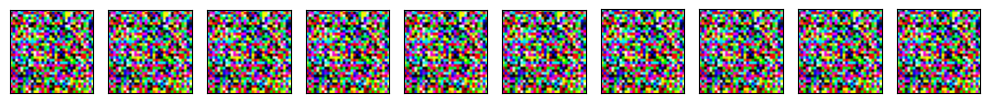

Epoch:   6/25 Discriminator Loss:  0.3319  Generator Loss:  0.0210
Epoch:   7/25 Discriminator Loss:  0.3313  Generator Loss:  0.0246
Epoch:   8/25 Discriminator Loss:  0.3308  Generator Loss:  0.0271
Epoch:   9/25 Discriminator Loss:  0.3304  Generator Loss:  0.0288
Epoch:  10/25 Discriminator Loss:  0.3301  Generator Loss:  0.0319


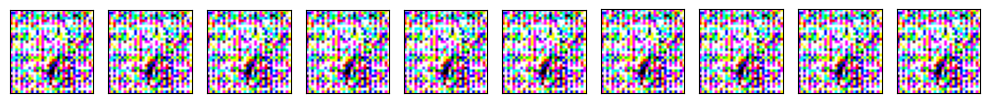

Epoch:  11/25 Discriminator Loss:  0.3298  Generator Loss:  0.0356
Epoch:  12/25 Discriminator Loss:  0.3297  Generator Loss:  0.0378
Epoch:  13/25 Discriminator Loss:  0.3294  Generator Loss:  0.0364
Epoch:  14/25 Discriminator Loss:  0.3292  Generator Loss:  0.0351
Epoch:  15/25 Discriminator Loss:  0.3291  Generator Loss:  0.0343


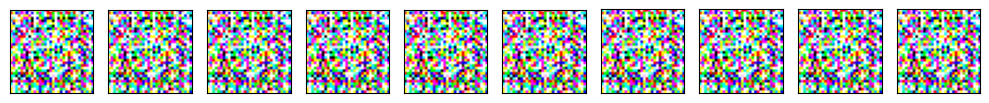

Epoch:  16/25 Discriminator Loss:  0.3289  Generator Loss:  0.0340
Epoch:  17/25 Discriminator Loss:  0.3288  Generator Loss:  0.0345
Epoch:  18/25 Discriminator Loss:  0.3286  Generator Loss:  0.0383
Epoch:  19/25 Discriminator Loss:  0.3285  Generator Loss:  0.0438
Epoch:  20/25 Discriminator Loss:  0.3284  Generator Loss:  0.0510


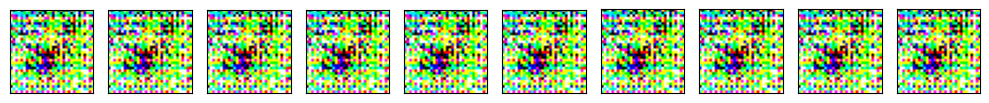

Epoch:  21/25 Discriminator Loss:  0.3283  Generator Loss:  0.0565
Epoch:  22/25 Discriminator Loss:  0.3282  Generator Loss:  0.0613
Epoch:  23/25 Discriminator Loss:  0.3281  Generator Loss:  0.0669
Epoch:  24/25 Discriminator Loss:  0.3280  Generator Loss:  0.0713
Epoch:  25/25 Discriminator Loss:  0.3279  Generator Loss:  0.0745


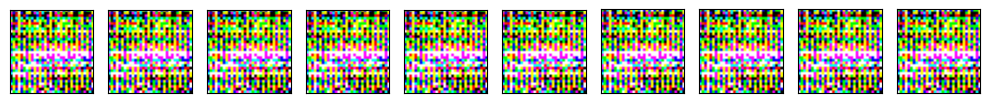

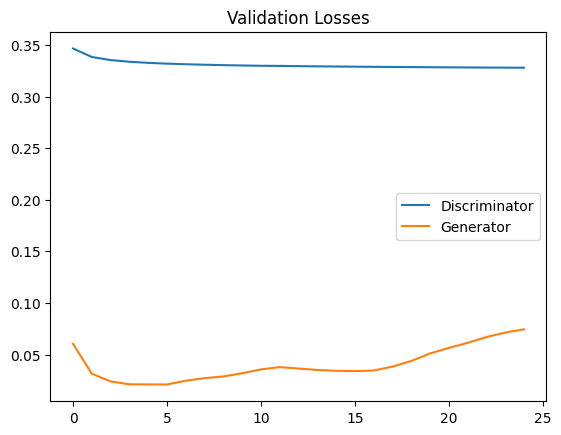

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step


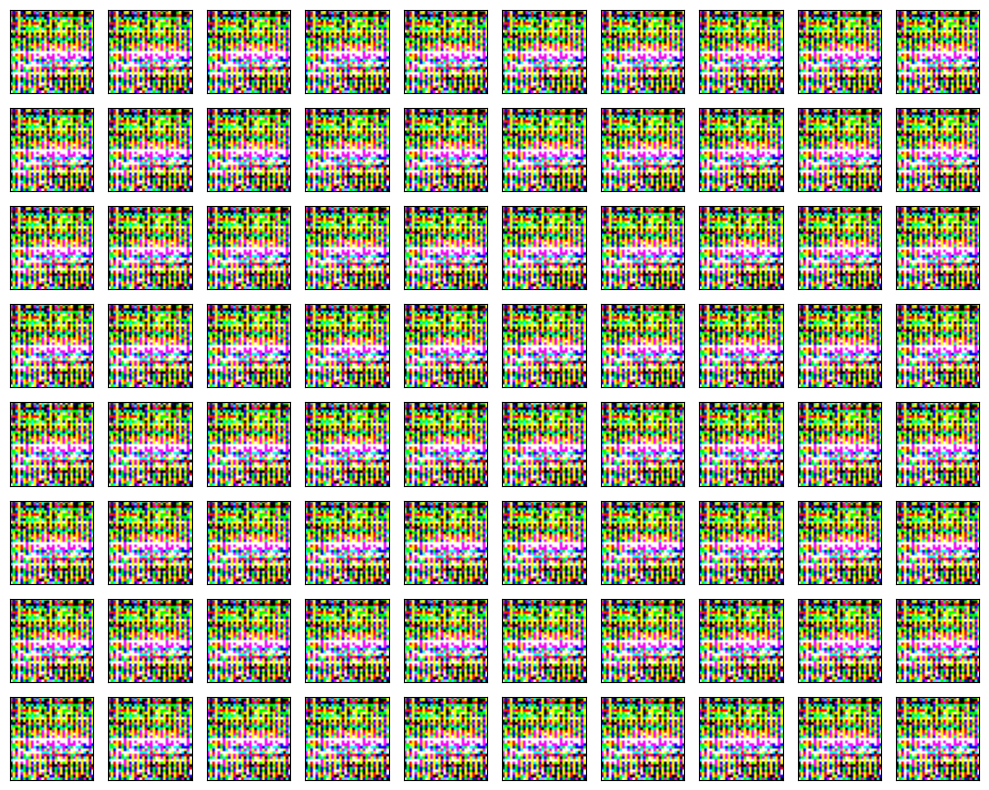

In [ ]:
train(g_learning_rate=0.0002, g_beta_1=0.5, d_learning_rate=0.0002, d_beta_1=0.5, leaky_alpha=0.2);

Epoch:   1/25 Discriminator Loss:  0.3721  Generator Loss:  0.0498
Epoch:   2/25 Discriminator Loss:  0.3525  Generator Loss:  0.0440
Epoch:   3/25 Discriminator Loss:  0.3453  Generator Loss:  0.0541
Epoch:   4/25 Discriminator Loss:  0.3517  Generator Loss:  0.0940
Epoch:   5/25 Discriminator Loss:  0.3479  Generator Loss:  0.0838


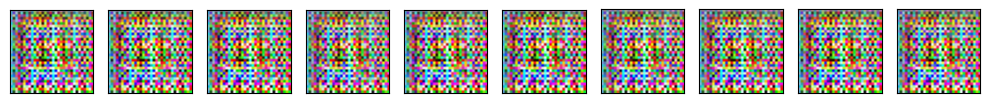

Epoch:   6/25 Discriminator Loss:  0.3452  Generator Loss:  0.0749
Epoch:   7/25 Discriminator Loss:  0.3431  Generator Loss:  0.0772
Epoch:   8/25 Discriminator Loss:  0.3414  Generator Loss:  0.0951
Epoch:   9/25 Discriminator Loss:  0.3398  Generator Loss:  0.1203
Epoch:  10/25 Discriminator Loss:  0.3393  Generator Loss:  0.1463


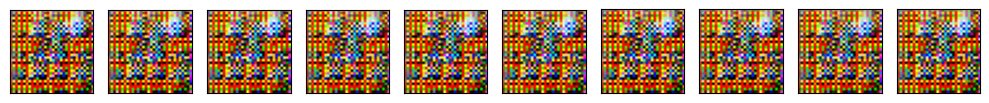

Epoch:  11/25 Discriminator Loss:  0.3382  Generator Loss:  0.1442


In [ ]:
train(g_learning_rate=0.0001, g_beta_1=0.5, d_learning_rate=0.001, d_beta_1=0.5, leaky_alpha=0.2);